In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# load data
df = pd.read_csv("New York Citi Bike Trip Histories 2015 - 2017.csv")

# convert time columns
df["Start Time"] = pd.to_datetime(df["Start Time"], errors="coerce")
df["Stop Time"] = pd.to_datetime(df["Stop Time"], errors="coerce")

## VA - Start Time

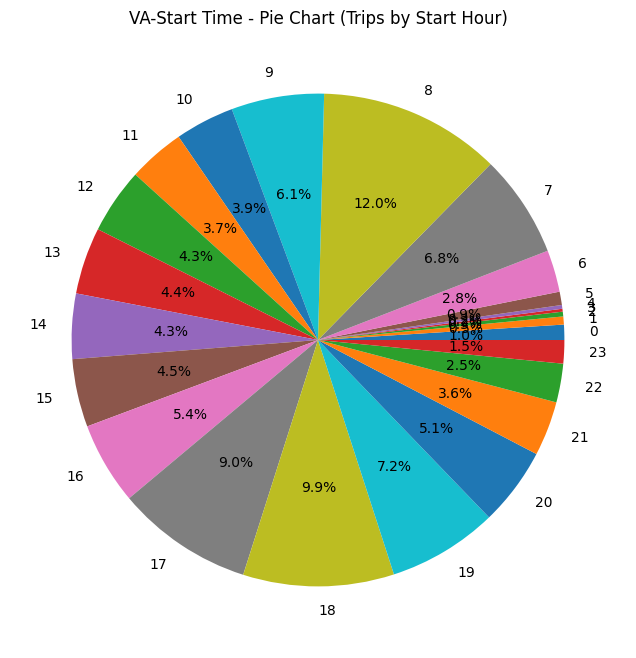

In [2]:
start_hour = df["Start Time"].dt.hour.dropna()
hour_counts = start_hour.value_counts().sort_index()

# Pie Chart
plt.figure(figsize=(8, 8))
hour_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("VA-Start Time - Pie Chart (Trips by Start Hour)")
plt.ylabel("")
plt.show()

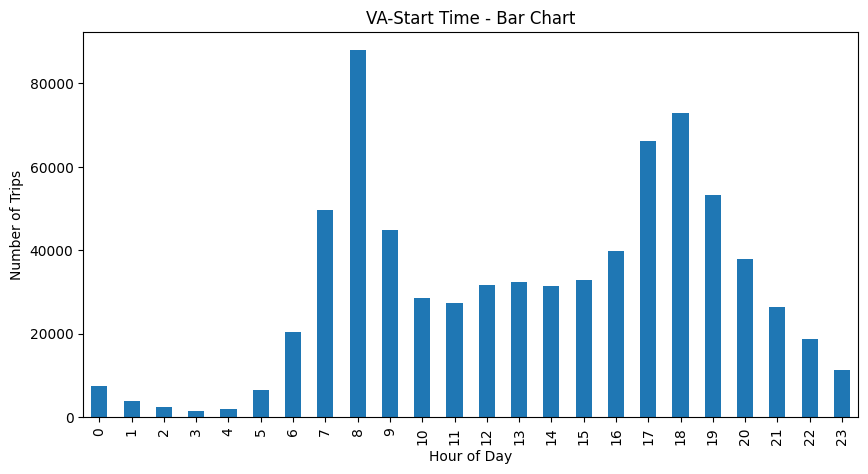

In [3]:
plt.figure(figsize=(10, 5))
hour_counts.plot(kind="bar")
plt.title("VA-Start Time - Bar Chart")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

<Figure size 1000x500 with 0 Axes>

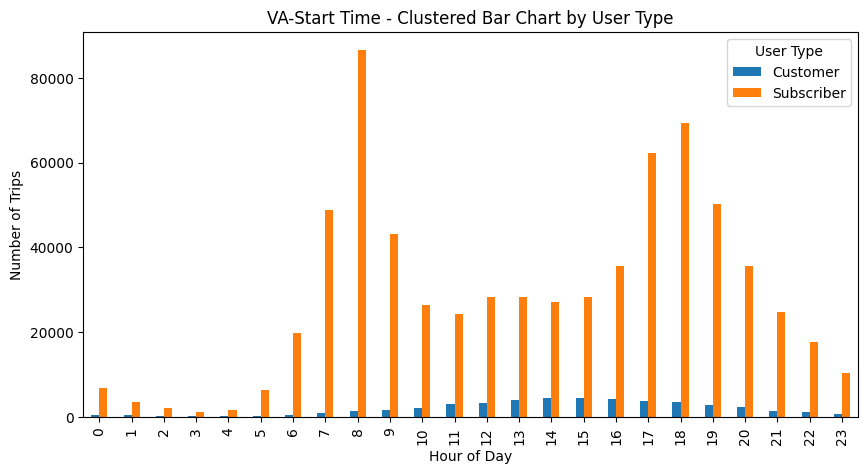

<Figure size 1000x500 with 0 Axes>

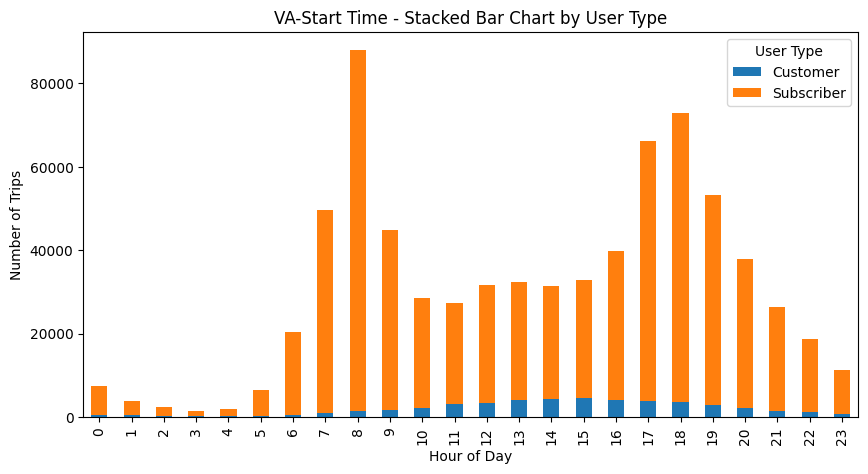

In [4]:
start_user = pd.crosstab(df["Start Time"].dt.hour, df["User Type"])

plt.figure(figsize=(10, 5))
start_user.plot(kind="bar", stacked=False, figsize=(10, 5))
plt.title("VA-Start Time - Clustered Bar Chart by User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

plt.figure(figsize=(10, 5))
start_user.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("VA-Start Time - Stacked Bar Chart by User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

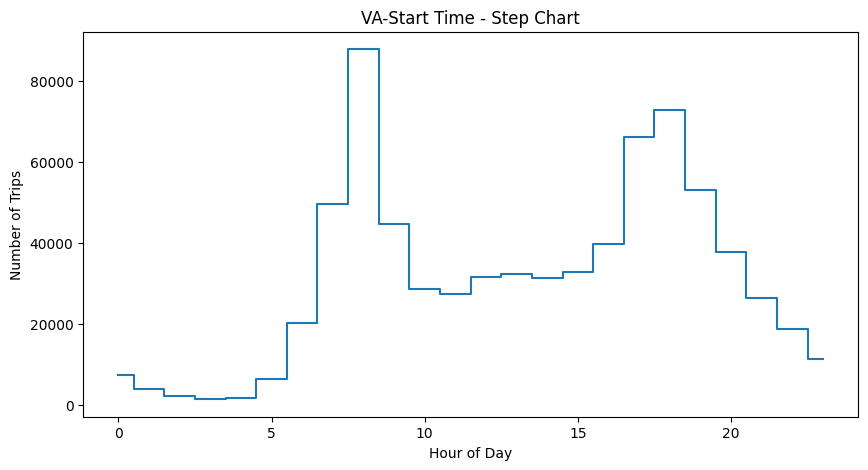

In [5]:
plt.figure(figsize=(10, 5))
plt.step(hour_counts.index, hour_counts.values, where="mid")
plt.title("VA-Start Time - Step Chart")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

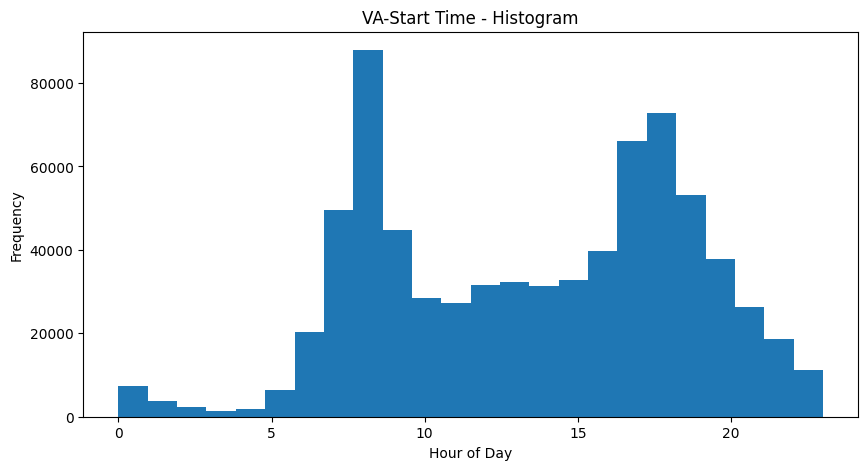

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(start_hour, bins=24)
plt.title("VA-Start Time - Histogram")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")
plt.show()

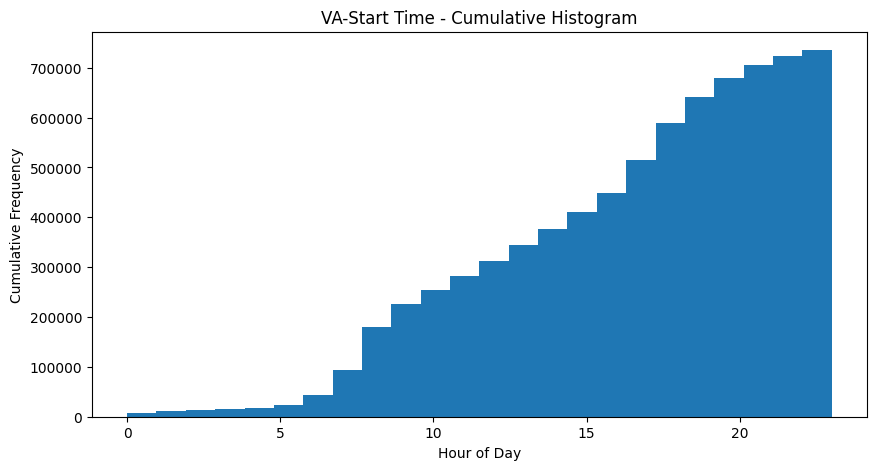

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(start_hour, bins=24, cumulative=True)
plt.title("VA-Start Time - Cumulative Histogram")
plt.xlabel("Hour of Day")
plt.ylabel("Cumulative Frequency")
plt.show()

## VA - Stop Time

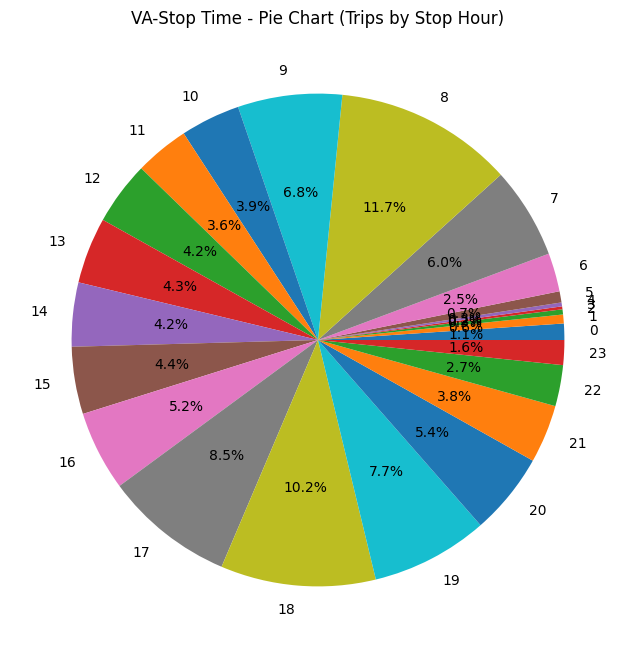

In [8]:
stop_hour = df["Stop Time"].dt.hour.dropna()
hour_counts = stop_hour.value_counts().sort_index()


plt.figure(figsize=(8, 8))
hour_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("VA-Stop Time - Pie Chart (Trips by Stop Hour)")
plt.ylabel("")
plt.show()

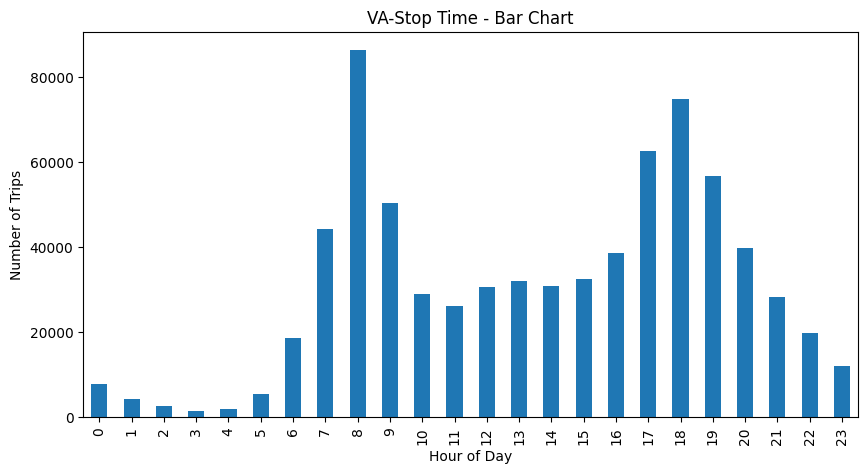

In [9]:
plt.figure(figsize=(10, 5))
hour_counts.plot(kind="bar")
plt.title("VA-Stop Time - Bar Chart")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()


<Figure size 1000x500 with 0 Axes>

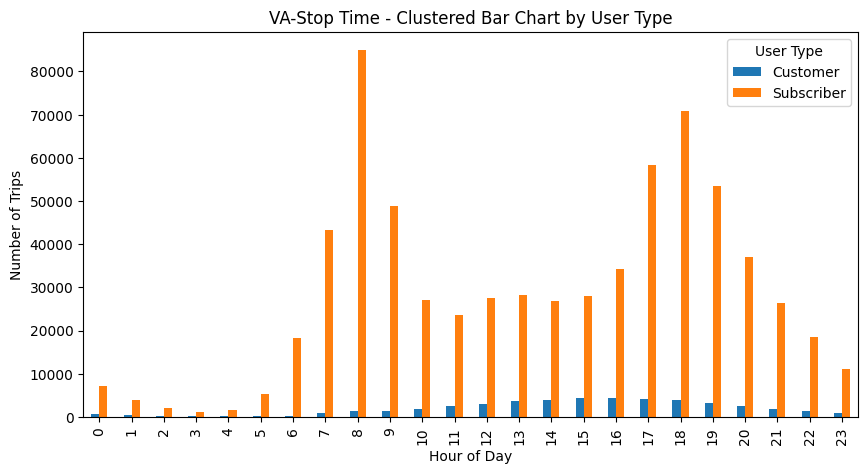

<Figure size 1000x500 with 0 Axes>

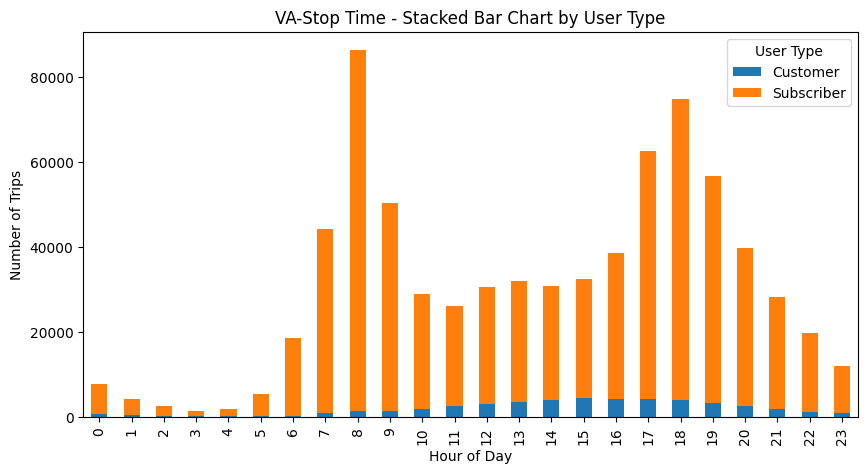

In [10]:
stop_user = pd.crosstab(df["Stop Time"].dt.hour, df["User Type"])

plt.figure(figsize=(10, 5))
stop_user.plot(kind="bar", stacked=False, figsize=(10, 5))
plt.title("VA-Stop Time - Clustered Bar Chart by User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

plt.figure(figsize=(10, 5))
stop_user.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("VA-Stop Time - Stacked Bar Chart by User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

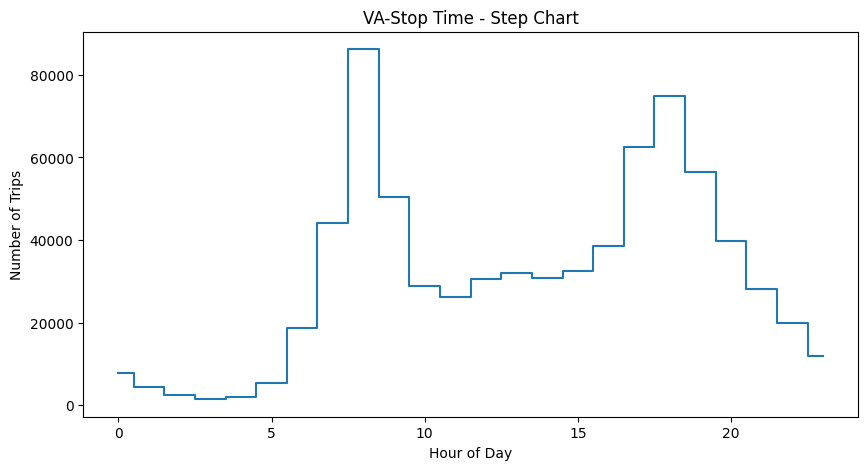

In [11]:
plt.figure(figsize=(10, 5))
plt.step(hour_counts.index, hour_counts.values, where="mid")
plt.title("VA-Stop Time - Step Chart")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

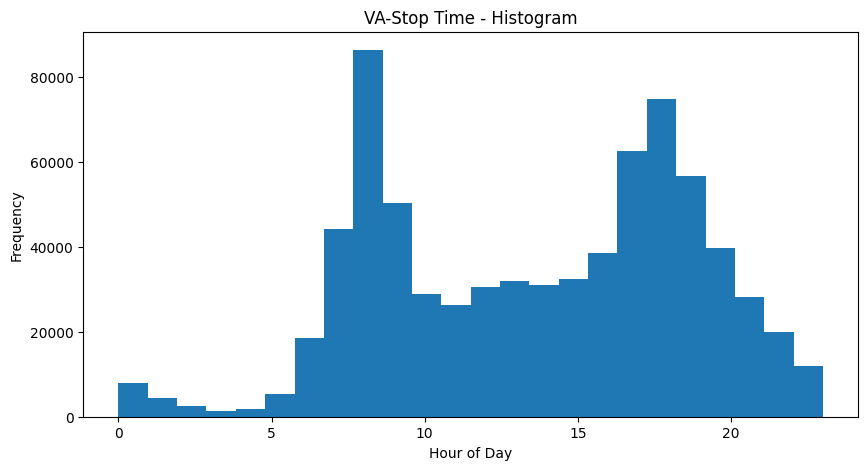

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(stop_hour, bins=24)
plt.title("VA-Stop Time - Histogram")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")
plt.show()

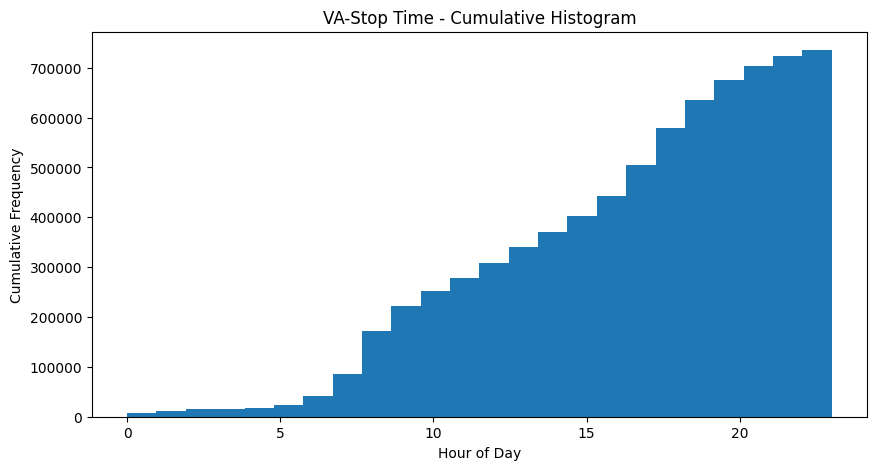

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(stop_hour, bins=24, cumulative=True)
plt.title("VA-Stop Time - Cumulative Histogram")
plt.xlabel("Hour of Day")
plt.ylabel("Cumulative Frequency")
plt.show()

## VA - Start Station ID

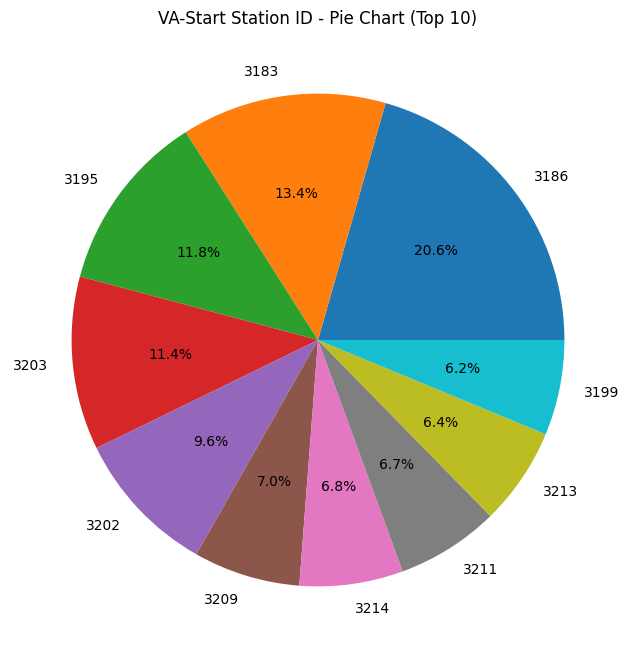

In [14]:
top_start_id = df["Start Station ID"].astype(str).value_counts().head(10)


plt.figure(figsize=(8, 8))
top_start_id.plot(kind="pie", autopct="%1.1f%%")
plt.title("VA-Start Station ID - Pie Chart (Top 10)")
plt.ylabel("")
plt.show()

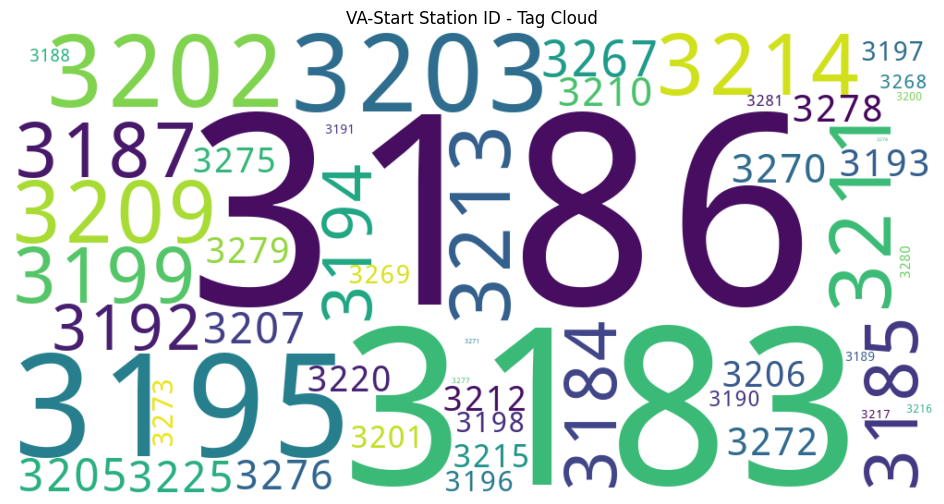

In [20]:
start_id_freq = df["Start Station ID"].dropna().astype(str).value_counts().to_dict()

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate_from_frequencies(start_id_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("VA-Start Station ID - Tag Cloud")
plt.show()

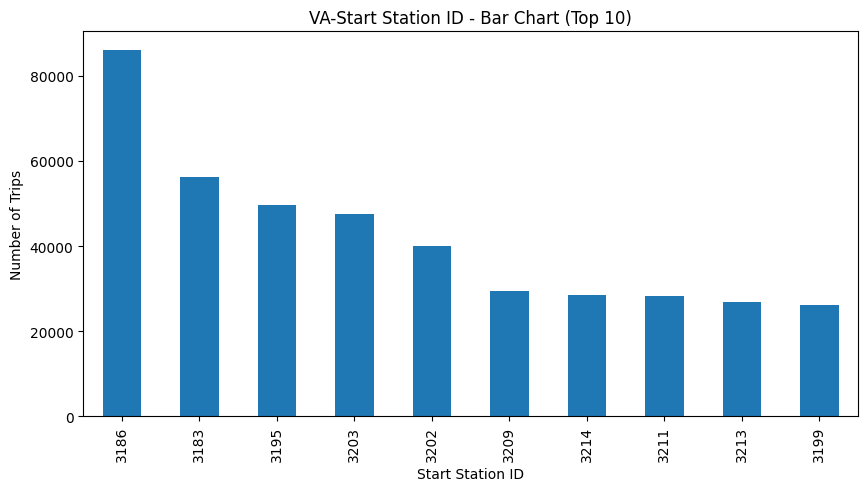

In [17]:
plt.figure(figsize=(10, 5))
top_start_id.plot(kind="bar")
plt.title("VA-Start Station ID - Bar Chart (Top 10)")
plt.xlabel("Start Station ID")
plt.ylabel("Number of Trips")
plt.show()

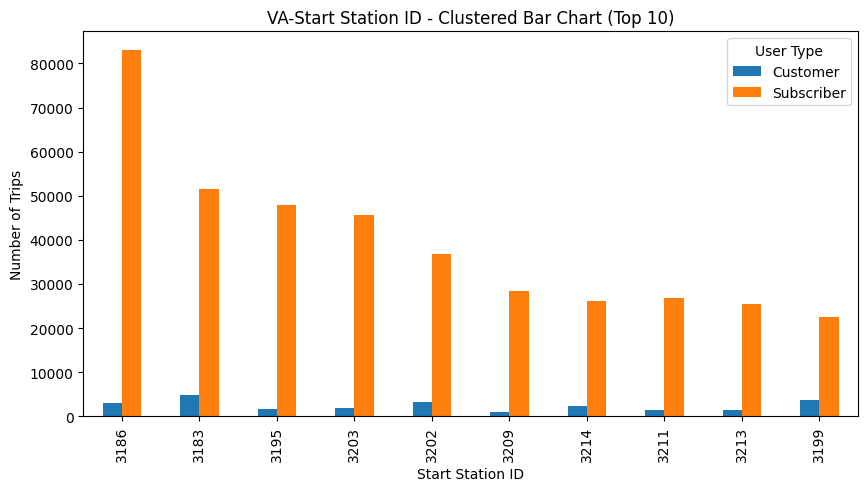

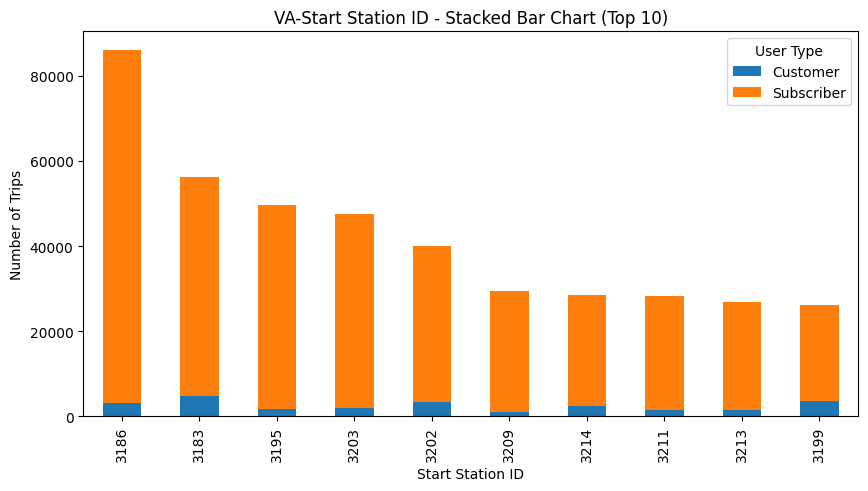

In [19]:
start_id_user = pd.crosstab(df["Start Station ID"], df["User Type"])
start_id_user = start_id_user.loc[top_start_id.index.astype(float, errors="ignore") if False else start_id_user.index.intersection(top_start_id.index)]


start_id_user = pd.crosstab(df["Start Station ID"].astype(str), df["User Type"]).loc[top_start_id.index]

start_id_user.plot(kind="bar", stacked=False, figsize=(10, 5))
plt.title("VA-Start Station ID - Clustered Bar Chart (Top 10)")
plt.xlabel("Start Station ID")
plt.ylabel("Number of Trips")
plt.show()


start_id_user.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("VA-Start Station ID - Stacked Bar Chart (Top 10)")
plt.xlabel("Start Station ID")
plt.ylabel("Number of Trips")
plt.show()


## VA - Station Name

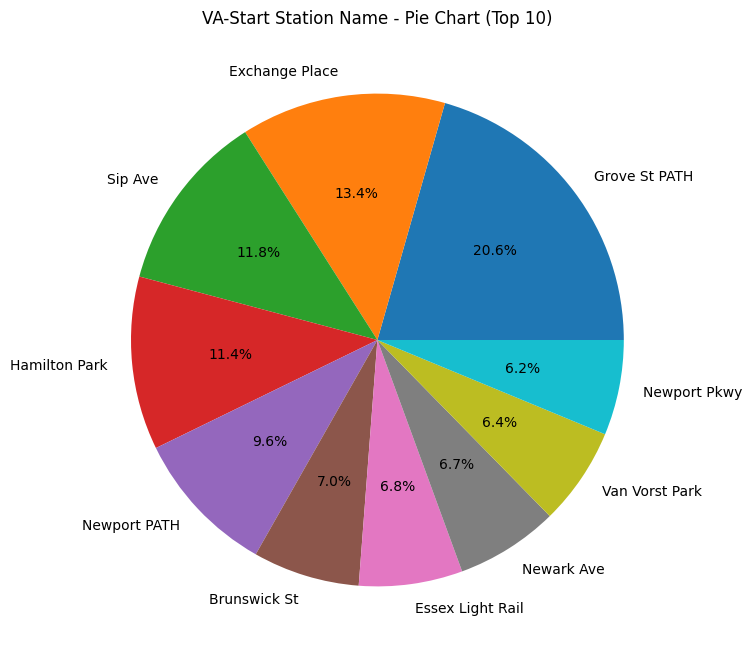

In [21]:
top_start_name = df["Start Station Name"].value_counts().head(10)

plt.figure(figsize=(8, 8))
top_start_name.plot(kind="pie", autopct="%1.1f%%")
plt.title("VA-Start Station Name - Pie Chart (Top 10)")
plt.ylabel("")
plt.show()

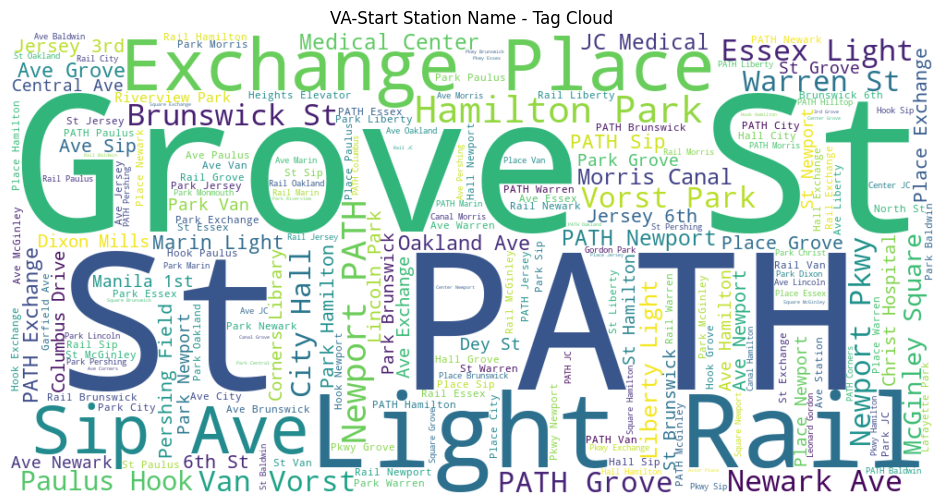

In [22]:
text = " ".join(df["Start Station Name"].dropna().astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("VA-Start Station Name - Tag Cloud")
plt.show()


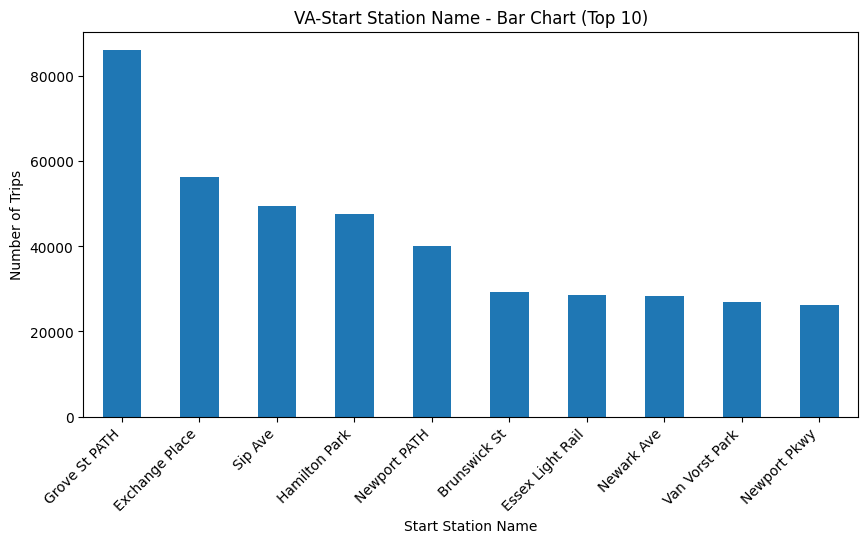

In [23]:
plt.figure(figsize=(10, 5))
top_start_name.plot(kind="bar")
plt.title("VA-Start Station Name - Bar Chart (Top 10)")
plt.xlabel("Start Station Name")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45, ha="right")
plt.show()

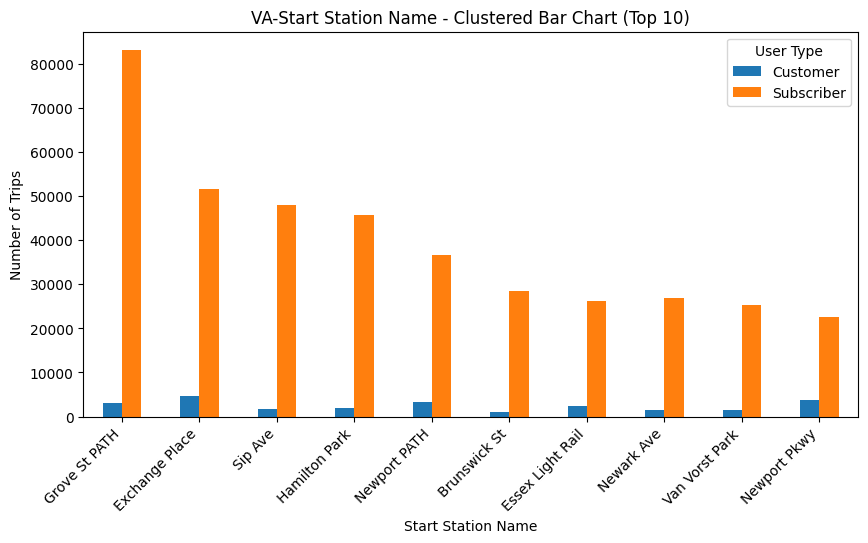

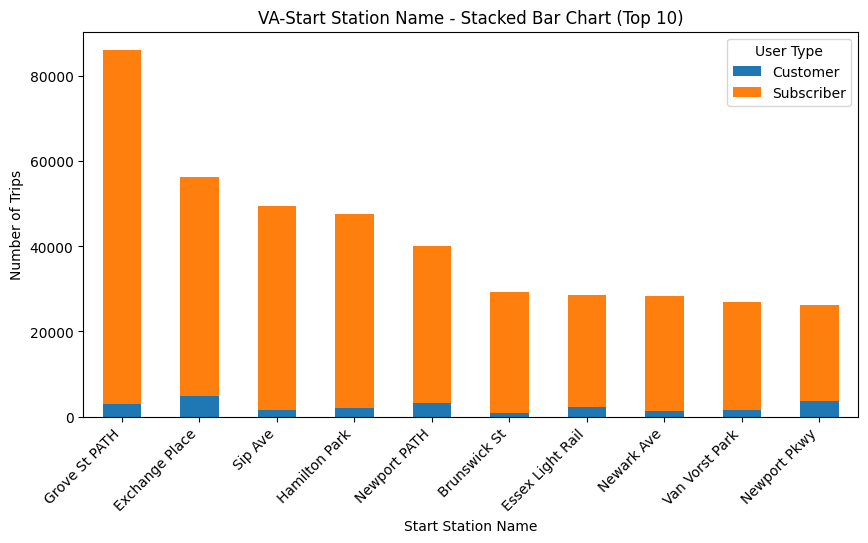

In [24]:
start_name_user = pd.crosstab(df["Start Station Name"], df["User Type"]).loc[top_start_name.index]

start_name_user.plot(kind="bar", stacked=False, figsize=(10, 5))
plt.title("VA-Start Station Name - Clustered Bar Chart (Top 10)")
plt.xlabel("Start Station Name")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45, ha="right")
plt.show()

start_name_user.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("VA-Start Station Name - Stacked Bar Chart (Top 10)")
plt.xlabel("Start Station Name")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45, ha="right")
plt.show()

## VA - Start Station Lattitude

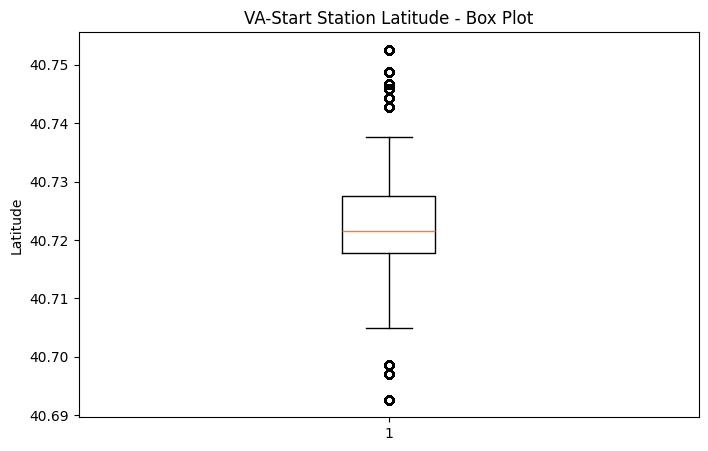

In [25]:
lat = df["Start Station Latitude"].dropna()


plt.figure(figsize=(8, 5))
plt.boxplot(lat, vert=True)
plt.title("VA-Start Station Latitude - Box Plot")
plt.ylabel("Latitude")
plt.show()

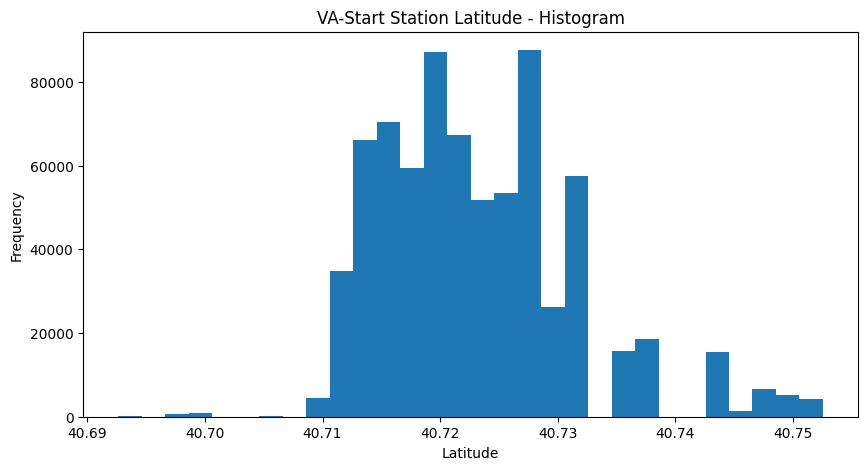

In [26]:
plt.figure(figsize=(10, 5))
plt.hist(lat, bins=30)
plt.title("VA-Start Station Latitude - Histogram")
plt.xlabel("Latitude")
plt.ylabel("Frequency")
plt.show()


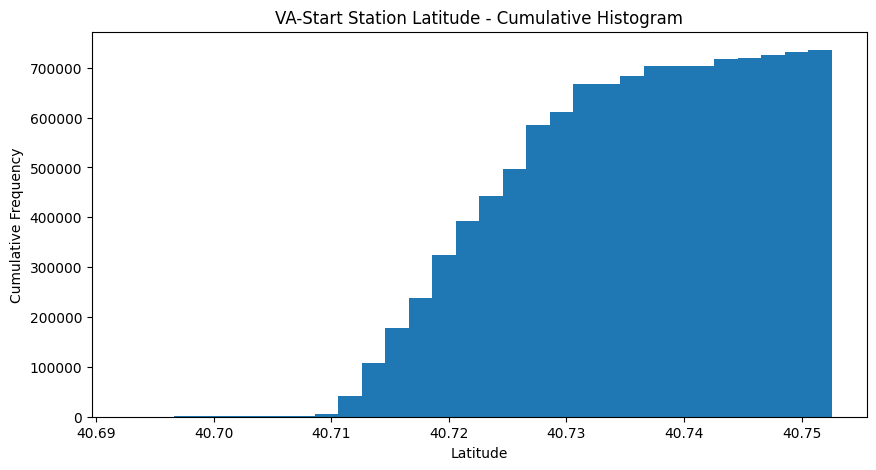

In [27]:
plt.figure(figsize=(10, 5))
plt.hist(lat, bins=30, cumulative=True)
plt.title("VA-Start Station Latitude - Cumulative Histogram")
plt.xlabel("Latitude")
plt.ylabel("Cumulative Frequency")
plt.show()

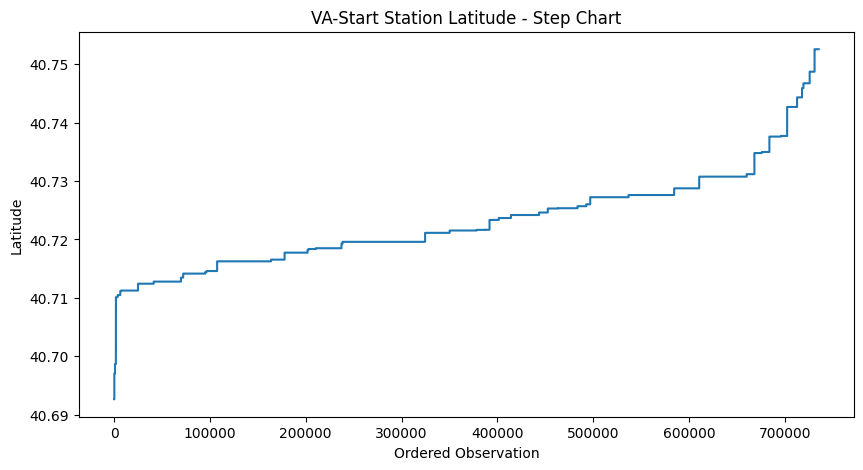

In [28]:
lat_sorted = lat.sort_values().reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.step(range(len(lat_sorted)), lat_sorted, where="mid")
plt.title("VA-Start Station Latitude - Step Chart")
plt.xlabel("Ordered Observation")
plt.ylabel("Latitude")
plt.show()

# VA - Start Station Longitude

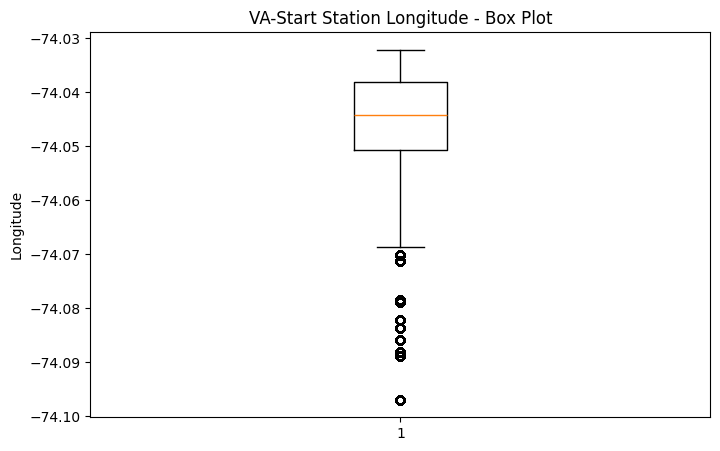

In [29]:
lon = df["Start Station Longitude"].dropna()


plt.figure(figsize=(8, 5))
plt.boxplot(lon, vert=True)
plt.title("VA-Start Station Longitude - Box Plot")
plt.ylabel("Longitude")
plt.show()

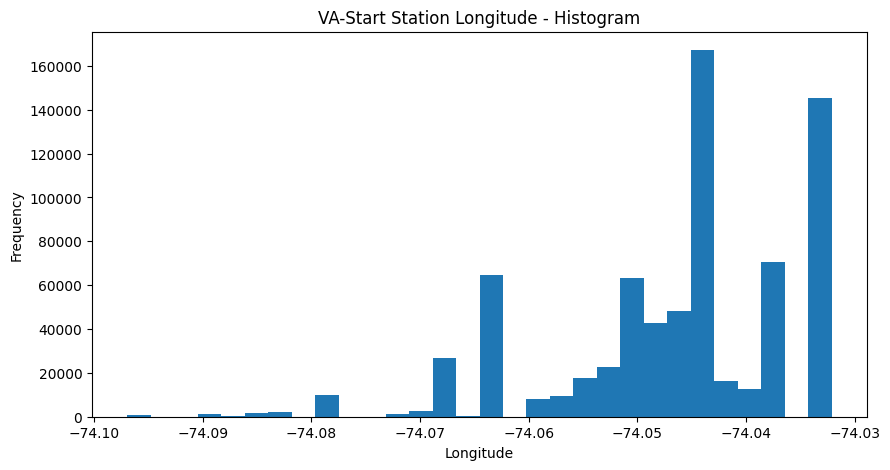

In [30]:
plt.figure(figsize=(10, 5))
plt.hist(lon, bins=30)
plt.title("VA-Start Station Longitude - Histogram")
plt.xlabel("Longitude")
plt.ylabel("Frequency")
plt.show()

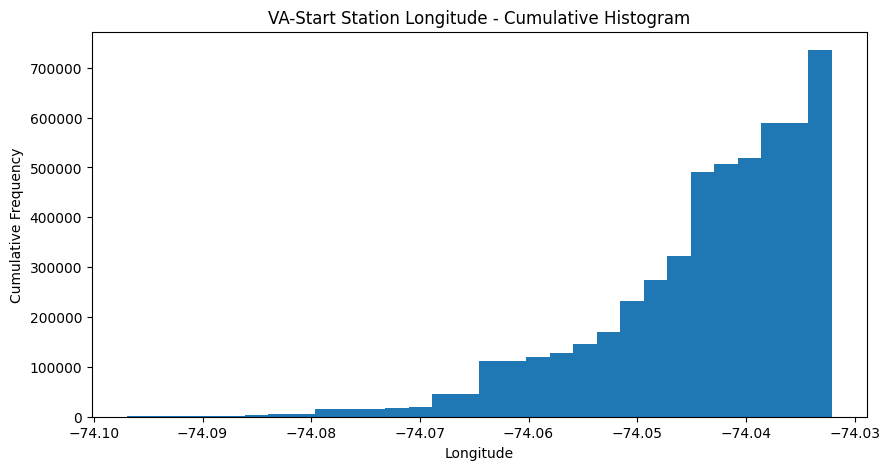

In [31]:
plt.figure(figsize=(10, 5))
plt.hist(lon, bins=30, cumulative=True)
plt.title("VA-Start Station Longitude - Cumulative Histogram")
plt.xlabel("Longitude")
plt.ylabel("Cumulative Frequency")
plt.show()

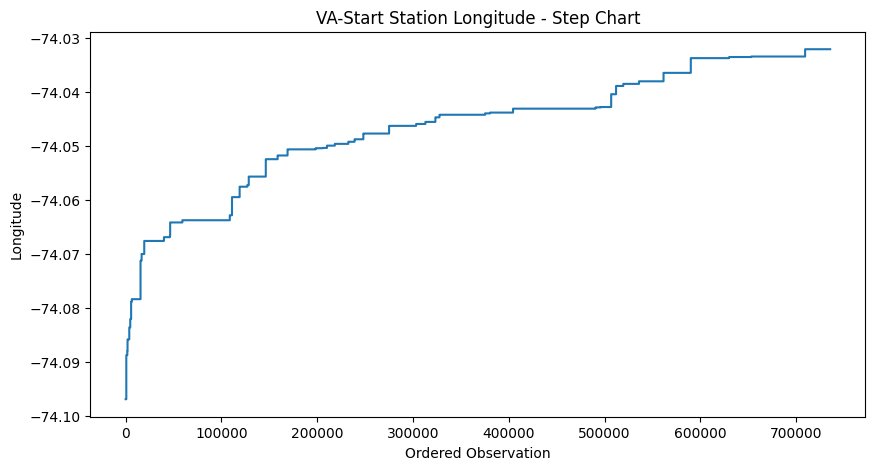

In [32]:
lon_sorted = lon.sort_values().reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.step(range(len(lon_sorted)), lon_sorted, where="mid")
plt.title("VA-Start Station Longitude - Step Chart")
plt.xlabel("Ordered Observation")
plt.ylabel("Longitude")
plt.show()

## VA - End Station ID

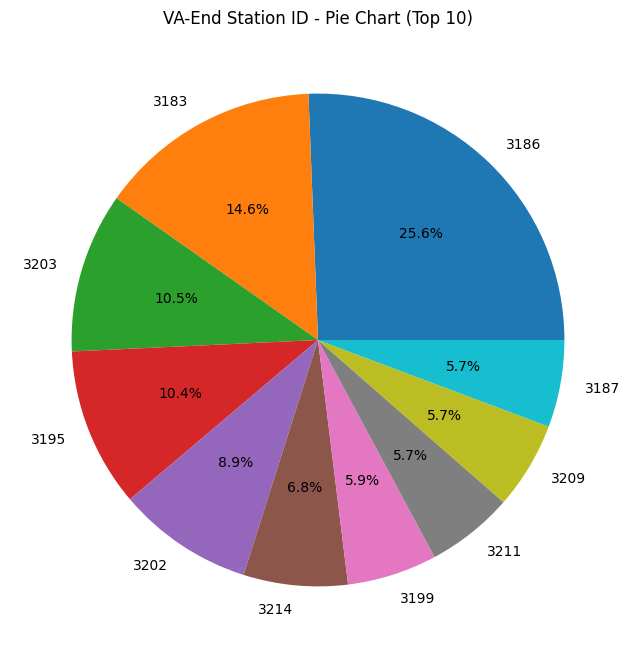

In [33]:
top_end_id = df["End Station ID"].astype(str).value_counts().head(10)


plt.figure(figsize=(8, 8))
top_end_id.plot(kind="pie", autopct="%1.1f%%")
plt.title("VA-End Station ID - Pie Chart (Top 10)")
plt.ylabel("")
plt.show()

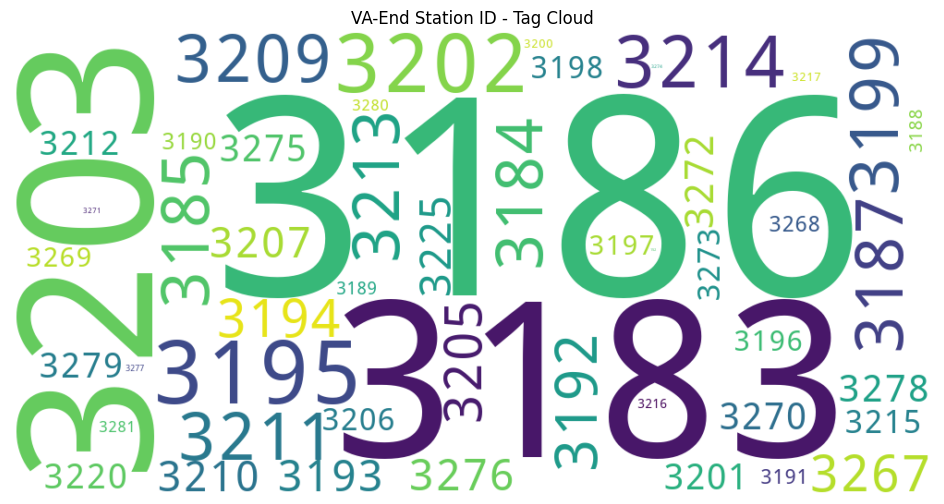

In [34]:
end_id_freq = df["End Station ID"].dropna().astype(str).value_counts().to_dict()

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate_from_frequencies(end_id_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("VA-End Station ID - Tag Cloud")
plt.show()

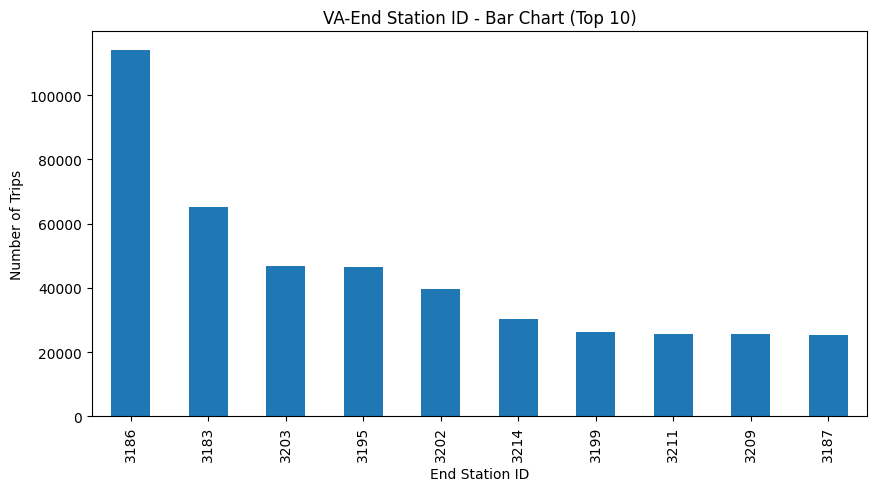

In [35]:
plt.figure(figsize=(10, 5))
top_end_id.plot(kind="bar")
plt.title("VA-End Station ID - Bar Chart (Top 10)")
plt.xlabel("End Station ID")
plt.ylabel("Number of Trips")
plt.show()

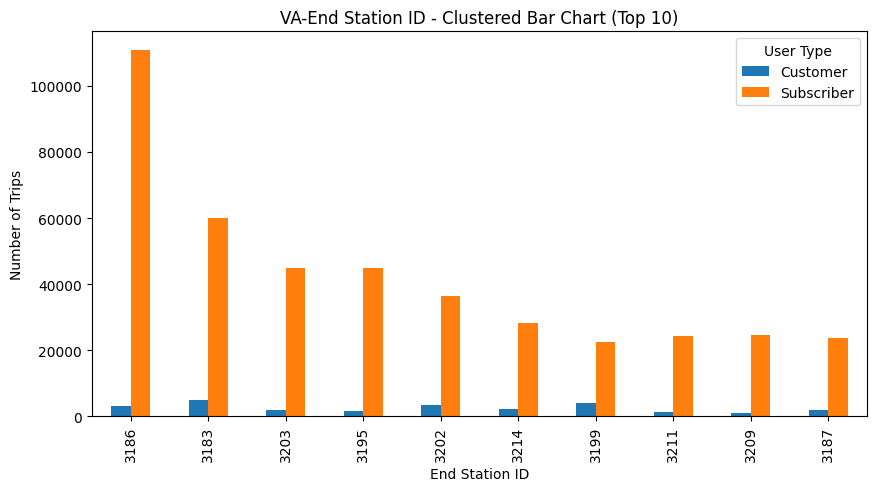

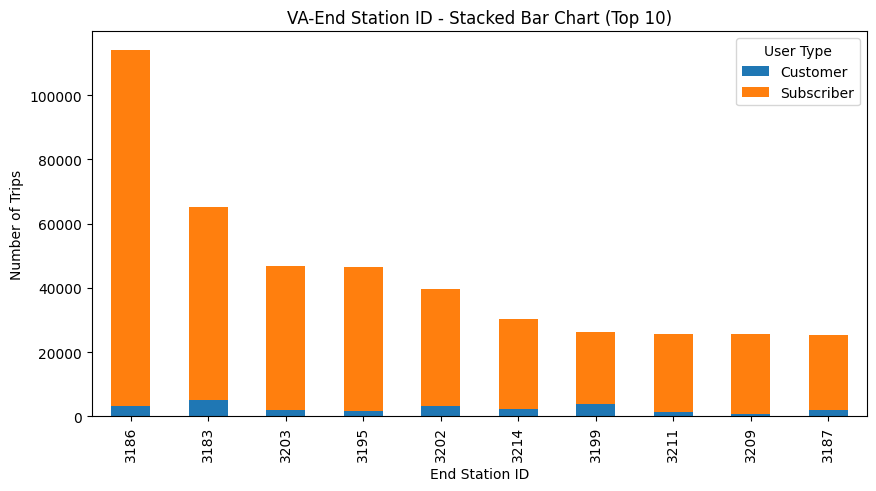

In [36]:
end_id_user = pd.crosstab(df["End Station ID"].astype(str), df["User Type"]).loc[top_end_id.index]

end_id_user.plot(kind="bar", stacked=False, figsize=(10, 5))
plt.title("VA-End Station ID - Clustered Bar Chart (Top 10)")
plt.xlabel("End Station ID")
plt.ylabel("Number of Trips")
plt.show()

end_id_user.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("VA-End Station ID - Stacked Bar Chart (Top 10)")
plt.xlabel("End Station ID")
plt.ylabel("Number of Trips")
plt.show()

## VA - End Station Name

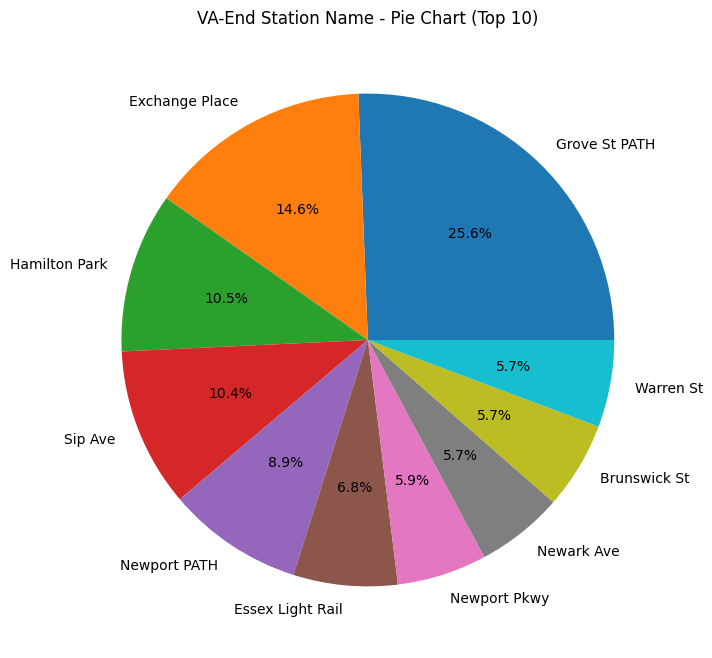

In [37]:
top_end_name = df["End Station Name"].value_counts().head(10)


plt.figure(figsize=(8, 8))
top_end_name.plot(kind="pie", autopct="%1.1f%%")
plt.title("VA-End Station Name - Pie Chart (Top 10)")
plt.ylabel("")
plt.show()

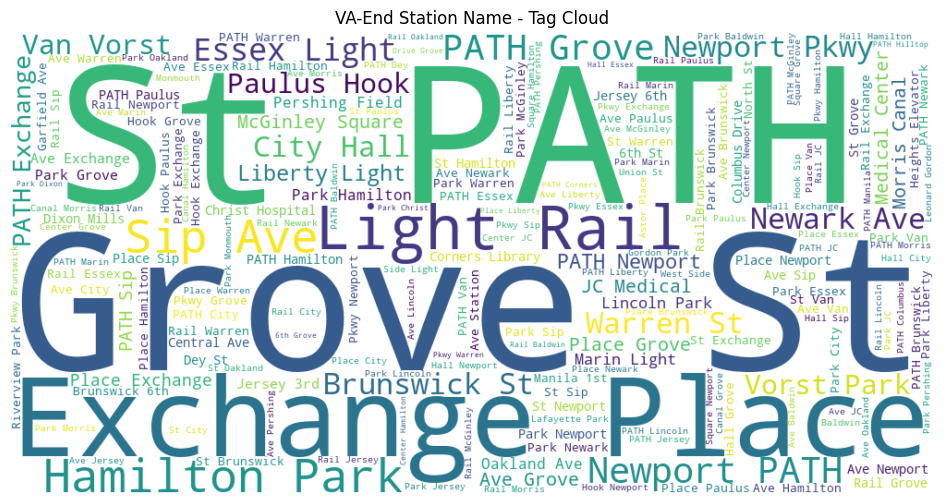

In [38]:
text = " ".join(df["End Station Name"].dropna().astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("VA-End Station Name - Tag Cloud")
plt.show()


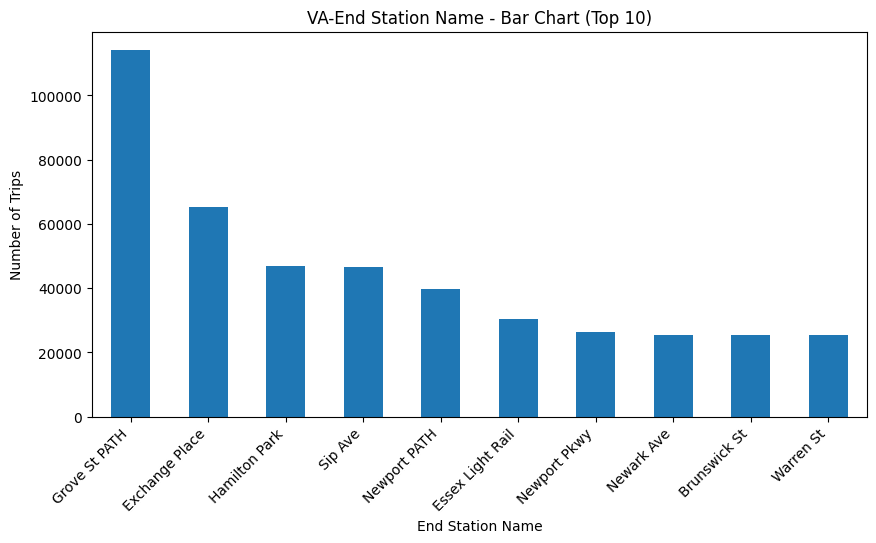

In [39]:
plt.figure(figsize=(10, 5))
top_end_name.plot(kind="bar")
plt.title("VA-End Station Name - Bar Chart (Top 10)")
plt.xlabel("End Station Name")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45, ha="right")
plt.show()

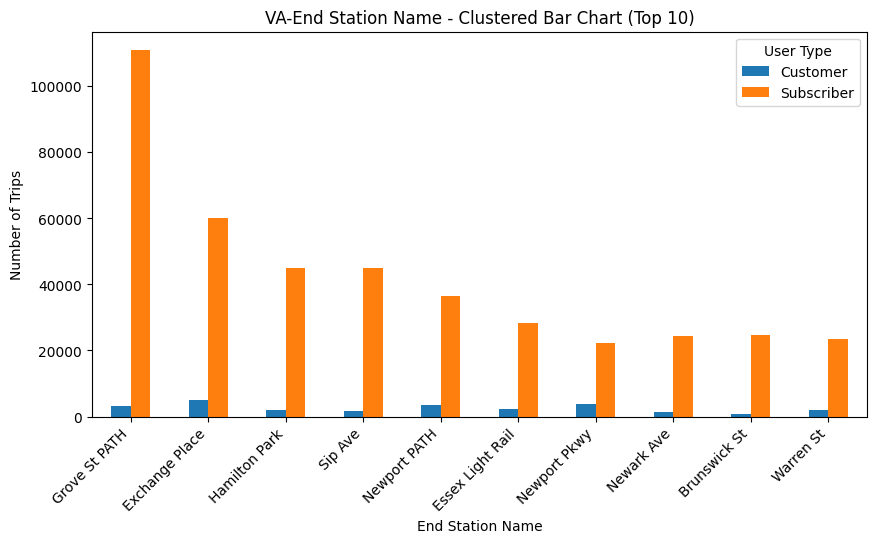

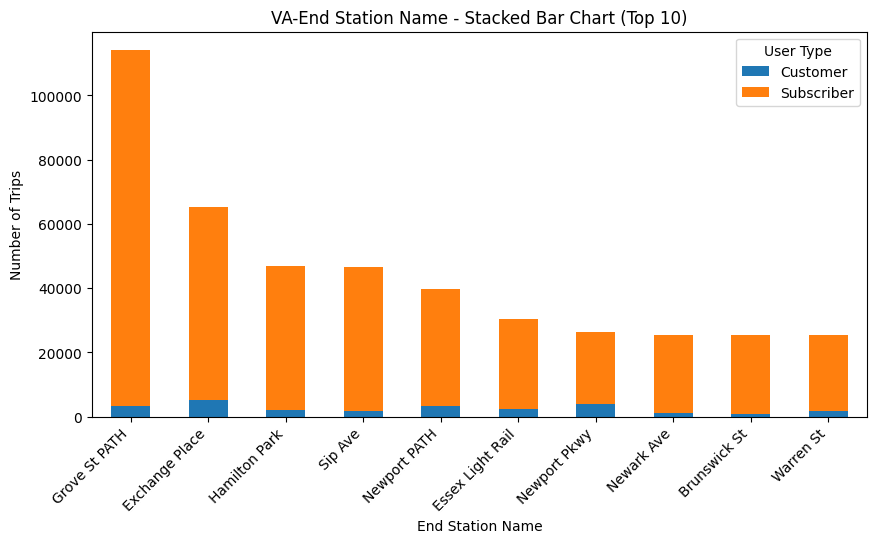

In [40]:
end_name_user = pd.crosstab(df["End Station Name"], df["User Type"]).loc[top_end_name.index]

end_name_user.plot(kind="bar", stacked=False, figsize=(10, 5))
plt.title("VA-End Station Name - Clustered Bar Chart (Top 10)")
plt.xlabel("End Station Name")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45, ha="right")
plt.show()

end_name_user.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("VA-End Station Name - Stacked Bar Chart (Top 10)")
plt.xlabel("End Station Name")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45, ha="right")
plt.show()